In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, mean_absolute_error
import pickle, json, warnings
warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f'TensorFlow: {tf.__version__}')
print(f'GPU: {len(tf.config.list_physical_devices("GPU")) > 0}')

TensorFlow: 2.20.0
GPU: True


In [11]:
import pandas as pd
import numpy as np
df = pd.read_csv('databersihowi.csv')

# Perbaikan rasio (income tahunan, expense bulanan)
df['monthly_income'] = df['income'] / 12.0
df['expense_ratio'] = (df['total_expense'] / df['monthly_income']).clip(0, 1)
df['saving_ratio'] = 1 - df['expense_ratio']

# 7 Fitur sesuai spesifikasi bisnis
df['income_log'] = np.log1p(df['income'])
df['lifestyle_burden'] = (df['lifestyle_expense'] / df['monthly_income']).clip(0, 1)
df['debt_burden'] = df['loan_int_rate'] / 20.0
df['credit_norm'] = (df['credit_score'] - 300) / 549.0
# family_size dan age langsung digunakan

# Target klasifikasi (budget_status dari CSV)
budget_map = {'Good': 2, 'Average': 1, 'Bad': 0}
df['budget_encoded'] = df['budget_status'].map(budget_map)

FEATURES = [
    'income_log', 'expense_ratio', 'lifestyle_burden',
    'debt_burden', 'credit_norm', 'family_size', 'age'
]

X = df[FEATURES].values.astype(np.float32)
# Target regresi: expense_ratio (bukan saving_ratio)
y_ratio = df['expense_ratio'].values.astype(np.float32)
print(f'Expense ratio mean/std: {y_ratio.mean():.4f}/{y_ratio.std():.4f}')
y_cat = df['budget_encoded'].values.astype(np.int32)

print(f'Dataset shape: {X.shape}')
print(f'Saving ratio mean/std: {y_ratio.mean():.4f}/{y_ratio.std():.4f}')

Expense ratio mean/std: 0.1570/0.1904
Dataset shape: (31856, 7)
Saving ratio mean/std: 0.1570/0.1904


In [12]:
def allocation_target(saving_ratio, budget_class):
    sr = np.clip(saving_ratio, 0, 1)
    if budget_class == 0:   # Konservatif
        return np.array([70, 25, 5])
    elif budget_class == 1: # Moderat
        saham = int(np.clip(20 + sr * 20, 20, 35))
        reksadana = int(np.clip(15 - sr * 10, 10, 25))
        obligasi = 100 - saham - reksadana
        return np.array([reksadana, obligasi, saham])
    else:                   # Agresif
        saham = int(np.clip(40 + sr * 40, 40, 75))
        reksadana = int(np.clip(15 - sr * 10, 5, 15))
        obligasi = 100 - saham - reksadana
        return np.array([reksadana, obligasi, saham])


alloc_targets = np.array([allocation_target(sr, bc) for sr, bc in zip(df['saving_ratio'], df['budget_encoded'])])
y_alloc = alloc_targets / 100.0  # normalisasi ke [0,1] untuk softmax

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

SEED = 42

X_tmp, X_test, yr_tmp, yr_test, yc_tmp, yc_test, ya_tmp, ya_test = train_test_split(
    X, y_ratio, y_cat, y_alloc, test_size=0.15, random_state=SEED, stratify=y_cat)
X_train, X_val, yr_train, yr_val, yc_train, yc_val, ya_train, ya_val = train_test_split(
    X_tmp, yr_tmp, yc_tmp, ya_tmp, test_size=0.176, random_state=SEED, stratify=yc_tmp)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s   = scaler.transform(X_val)
X_test_s  = scaler.transform(X_test)

print(f'Train: {len(X_train)}, Val: {len(X_val)}, Test: {len(X_test)}')


Train: 22311, Val: 4766, Test: 4779


In [14]:

# Sample weight untuk expense_ratio)
hist, bin_edges = np.histogram(yr_train, bins=20)
weights_reg = np.ones_like(yr_train, dtype=np.float32)
for i in range(len(bin_edges)-1):
    mask = (yr_train >= bin_edges[i]) & (yr_train < bin_edges[i+1])
    if mask.any():
        freq = hist[i] / len(yr_train)
        weight = 1.0 / (freq**2 + 1e-6)   # ekstrim
        weights_reg[mask] = weight
weights_reg = np.clip(weights_reg, 0.5, 30.0)
weights_reg = weights_reg / weights_reg.mean()

# Class weight untuk klasifikasi
from sklearn.utils.class_weight import compute_class_weight
cw = compute_class_weight('balanced', classes=np.unique(y_cat), y=y_cat)
class_weights = {i: cw[i] for i in range(len(cw))}
sample_weights_cat = np.array([class_weights[c] for c in yc_train], dtype=np.float32)

# Bobot total (regresi * klasifikasi)
sample_weights = weights_reg * sample_weights_cat
sample_weights = sample_weights / sample_weights.mean()

print(f'Sample weight range: {sample_weights.min():.2f} - {sample_weights.max():.2f}')

Sample weight range: 0.03 - 2.35


In [15]:
# Custom Layer: FinancialAttentionLayer (diperkuat)
class FinancialAttentionLayer(layers.Layer):
    def __init__(self, units=128, temperature=1.5, dropout_rate=0.2, **kwargs):
        super().__init__(**kwargs)
        self.units = units
        self.temperature = temperature
        self.dropout_rate = dropout_rate

    def build(self, input_shape):
        n = input_shape[-1]
        self.attn_w = self.add_weight(name='attn_w', shape=(n, n), initializer='glorot_uniform')
        self.attn_b = self.add_weight(name='attn_b', shape=(n,), initializer='zeros')
        self.proj_w = self.add_weight(name='proj_w', shape=(n, self.units), initializer='glorot_uniform')
        self.proj_b = self.add_weight(name='proj_b', shape=(self.units,), initializer='zeros')
        self.dropout = layers.Dropout(self.dropout_rate)
        super().build(input_shape)

    def call(self, inputs, training=False):
        scores = (tf.matmul(inputs, self.attn_w) + self.attn_b) / self.temperature
        weights = tf.nn.softmax(scores, axis=-1)
        attended = inputs * weights
        out = tf.nn.swish(tf.matmul(attended, self.proj_w) + self.proj_b)
        return self.dropout(out, training=training)

    def get_config(self):
        cfg = super().get_config()
        cfg.update({'units': self.units, 'temperature': self.temperature,
                    'dropout_rate': self.dropout_rate})
        return cfg

# Custom Loss: Weighted Huber (dengan sample weight)
class WeightedHuberLoss(keras.losses.Loss):
    def __init__(self, delta=0.05, name='weighted_huber', **kwargs):
        super().__init__(name=name, **kwargs)
        self.delta = delta

    def call(self, y_true, y_pred, sample_weight=None):
        y_true = tf.cast(y_true, tf.float32)
        y_pred = tf.cast(y_pred, tf.float32)
        error = y_true - y_pred
        abs_error = tf.abs(error)
        quadratic = tf.minimum(abs_error, self.delta)
        linear = abs_error - quadratic
        loss = 0.5 * quadratic**2 + self.delta * linear
        if sample_weight is not None:
            loss = loss * tf.cast(sample_weight, tf.float32)
        return tf.reduce_mean(loss)

# Custom Callback: Monitor MAE per segment saving ratio
class SegmentMAECallback(keras.callbacks.Callback):
    def __init__(self, X_val, y_val, bins=[0,0.15,0.35,0.5,1.0], every_epoch=5):
        super().__init__()
        self.X_val = X_val
        self.y_val = y_val
        self.bins = bins
        self.every = every_epoch

    def on_epoch_end(self, epoch, logs=None):
        if (epoch + 1) % self.every == 0:
            preds = self.model.predict(self.X_val, verbose=0)
            p_ratio = preds['ratio_output'].flatten()
            print(f"\n[Epoch {epoch+1}] MAE per segment saving ratio:")
            for i in range(len(self.bins)-1):
                mask = (self.y_val >= self.bins[i]) & (self.y_val < self.bins[i+1])
                if mask.any():
                    mae_bin = np.mean(np.abs(p_ratio[mask] - self.y_val[mask]))
                    print(f"  {self.bins[i]:.0%}-{self.bins[i+1]:.0%}: MAE={mae_bin:.5f} (n={mask.sum()})")

In [16]:
def build_model_allocation_focus(n_features=7):
    inp = keras.Input(shape=(n_features,))

    # Shared backbone (cukup dalam)
    x = layers.Dense(128, activation='relu')(inp)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.2)(x)

    # Head 1: Saving ratio (opsional, sebagai auxiliary)
    r = layers.Dense(32, activation='relu')(x)
    ratio_out = layers.Dense(1, activation='sigmoid', name='ratio_output')(r)

    # Head 2: Budget class (opsional)
    c = layers.Dense(32, activation='relu')(x)
    cat_out = layers.Dense(3, activation='softmax', name='cat_output')(c)

    # Head 3: Asset allocation (FOKUS UTAMA) → softmax
    a = layers.Dense(64, activation='relu', name='alloc_dense1')(x)
    a = layers.Dropout(0.2)(a)
    a = layers.Dense(32, activation='relu', name='alloc_dense2')(a)
    alloc_out = layers.Dense(3, activation='softmax', name='alloc_output')(a)

    model = Model(inputs=inp, outputs={
        'ratio_output': ratio_out,
        'cat_output': cat_out,
        'alloc_output': alloc_out
    })
    return model

model = build_model_allocation_focus(len(FEATURES))

In [17]:
initial_lr = 5e-4
total_epochs = 200
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=5e-4, clipnorm=0.5),
    loss={
        'ratio_output': 'mse',                     # Mean squared error untuk saving ratio
        'cat_output': 'sparse_categorical_crossentropy',
        'alloc_output': 'categorical_crossentropy'
    },
    loss_weights={
        'ratio_output': 1.0,      # kecil, karena hanya auxiliary
        'cat_output': 1.0,
        'alloc_output': 10.0      # BESAR, fokus ke alokasi
    },
    metrics={
        'ratio_output': ['mae'],
        'cat_output': ['accuracy'],
        'alloc_output': ['categorical_accuracy']
    }
)

In [40]:
initial_lr = 5e-4
total_epochs = 200
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=5e-4, clipnorm=0.5),
    loss={
        'ratio_output': 'mse',                     # Mean squared error untuk saving ratio
        'cat_output': 'sparse_categorical_crossentropy',
        'alloc_output': 'categorical_crossentropy'
    },
    loss_weights={
        'ratio_output': 1.0,      # kecil, karena hanya auxiliary
        'cat_output': 1.0,
        'alloc_output': 10.0      # BESAR, fokus ke alokasi
    },
    metrics={
        'ratio_output': ['mae'],
        'cat_output': ['accuracy'],
        'alloc_output': ['categorical_accuracy']
    }
)

y_train_dict = {
    'ratio_output': yr_train,
    'cat_output': yc_train,
    'alloc_output': ya_train   # dari langkah 1
}
y_val_dict = {
    'ratio_output': yr_val,
    'cat_output': yc_val,
    'alloc_output': ya_val
}

history = model.fit(
    X_train_s, y_train_dict,
    validation_data=(X_val_s, y_val_dict),
    epochs=150,
    batch_size=256,
    callbacks=[
        keras.callbacks.EarlyStopping(monitor='val_alloc_output_categorical_accuracy', patience=20, restore_best_weights=True, mode='max'),
        keras.callbacks.ReduceLROnPlateau(monitor='val_alloc_output_categorical_accuracy', factor=0.5, patience=10, mode='max')
    ],
    verbose=1
)

Epoch 1/150
88/88 ━━━━━━━━━━━━━━━━━━━━ 15s 74ms/step - alloc_output_categorical_accuracy: 0.7337 - alloc_output_loss: 1.0079 - cat_output_accuracy: 0.7597 - cat_output_loss: 0.5563 - loss: 10.6493 - ratio_output_loss: 0.0087 - ratio_output_mae: 0.0649 - val_alloc_output_categorical_accuracy: 0.7671 - val_alloc_output_loss: 1.0193 - val_cat_output_accuracy: 0.7914 - val_cat_output_loss: 0.5723 - val_loss: 10.7743 - val_ratio_output_loss: 0.0102 - val_ratio_output_mae: 0.0903 - learning_rate: 5.0000e-04
Epoch 2/150
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - alloc_output_categorical_accuracy: 0.7515 - alloc_output_loss: 1.0025 - cat_output_accuracy: 0.7696 - cat_output_loss: 0.5300 - loss: 10.5679 - ratio_output_loss: 0.0079 - ratio_output_mae: 0.0619 - val_alloc_output_categorical_accuracy: 0.7807 - val_alloc_output_loss: 1.0065 - val_cat_output_accuracy: 0.7940 - val_cat_output_loss: 0.5131 - val_loss: 10.5808 - val_ratio_output_loss: 0.0045 - val_ratio_output_mae: 0.0564 - learning_rate:

In [41]:
preds = model.predict(X_test_s, verbose=0)
p_alloc = preds['alloc_output']
p_alloc_pct = (p_alloc * 100).astype(int)
true_alloc_pct = ya_test * 100


alloc_mae = np.mean(np.abs(p_alloc_pct - true_alloc_pct))
print(f'Allocation MAE (percentage points): {alloc_mae:.2f}%')


pred_dominant = np.argmax(p_alloc, axis=1)
true_dominant = np.argmax(ya_test, axis=1)
alloc_class_acc = np.mean(pred_dominant == true_dominant)
print(f'Allocation dominant class accuracy: {alloc_class_acc:.2%}')

Allocation MAE (percentage points): 11.52%
Allocation dominant class accuracy: 81.80%


Allocation MAE (percentage points): 11.52%
Allocation dominant class accuracy: 81.80%


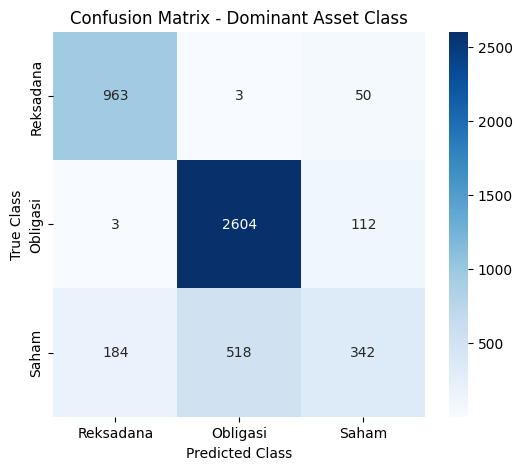


Classification Report - Dominant Asset Class:
              precision    recall  f1-score   support

   Reksadana       0.84      0.95      0.89      1016
    Obligasi       0.83      0.96      0.89      2719
       Saham       0.68      0.33      0.44      1044

    accuracy                           0.82      4779
   macro avg       0.78      0.74      0.74      4779
weighted avg       0.80      0.82      0.79      4779


MAE per Asset Component (percentage points):
  Reksadana: 10.90%
  Obligasi: 7.10%
  Saham: 16.56%


In [44]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt


preds = model.predict(X_test_s, verbose=0)
p_alloc = preds['alloc_output']                     # shape (n, 3) proporsi
p_alloc_pct = (p_alloc * 100).astype(int)
true_alloc_pct = ya_test * 100


alloc_mae = np.mean(np.abs(p_alloc_pct - true_alloc_pct))
print(f'Allocation MAE (percentage points): {alloc_mae:.2f}%')


pred_dominant = np.argmax(p_alloc, axis=1)
true_dominant = np.argmax(ya_test, axis=1)
alloc_class_acc = np.mean(pred_dominant == true_dominant)
print(f'Allocation dominant class accuracy: {alloc_class_acc:.2%}')

cm = confusion_matrix(true_dominant, pred_dominant)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Reksadana', 'Obligasi', 'Saham'],
            yticklabels=['Reksadana', 'Obligasi', 'Saham'])
plt.title('Confusion Matrix - Dominant Asset Class')
plt.ylabel('True Class')
plt.xlabel('Predicted Class')
plt.show()

print("\nClassification Report - Dominant Asset Class:")
print(classification_report(true_dominant, pred_dominant,
                            target_names=['Reksadana', 'Obligasi', 'Saham']))

print("\nMAE per Asset Component (percentage points):")
for i, name in enumerate(['Reksadana', 'Obligasi', 'Saham']):
    mae_comp = np.mean(np.abs(p_alloc_pct[:, i] - true_alloc_pct[:, i]))
    print(f'  {name}: {mae_comp:.2f}%')

In [20]:
# INFERENSI

import numpy as np


PROFIL_MAP = {
    0: 'Konservatif (Reksadana)',
    1: 'Moderat (Obligasi)',
    2: 'Agresif (Saham)'
}

def interpret_saving_ratio(ratio):
    if ratio >= 0.70: return 'Sangat Kuat (>70%)'
    if ratio >= 0.50: return 'Kuat (50–70%)'
    if ratio >= 0.35: return 'Cukup Baik (35–50%)'
    if ratio >= 0.15: return 'Moderat (15–35%)'
    if ratio >= 0.10: return 'Lemah (10–15%)'
    return 'Sangat Lemah (<10%)'

def predict_allocation(user_data, model, scaler):
    """
    Prediksi alokasi aset (Reksadana, Obligasi, Saham) langsung dari model ML.

    Parameters:
    user_data : dict dengan keys: income, total_expense, lifestyle_expense,
                loan_int_rate, credit_score, family_size, age
    model     : model Keras dengan output 'ratio_output', 'cat_output', 'alloc_output'
    scaler    : StandardScaler yang sudah di-fit

    Returns:
    dict berisi saving ratio, profil, dan alokasi (dalam persen)
    """
    # Ekstrak input
    income = user_data.get('income', 1)
    monthly_inc = income / 12.0
    total_exp = user_data.get('total_expense', 0)
    lifestyle = user_data.get('lifestyle_expense', 0)
    loan_rate = user_data.get('loan_int_rate', 10.0)
    credit = user_data.get('credit_score', 579)
    family = user_data.get('family_size', 2)
    age = user_data.get('age', 30)

    # Feature engineering (7 fitur sesuai spesifikasi)
    expense_ratio = np.clip(total_exp / (monthly_inc + 1e-6), 0, 1)
    saving_actual = 1 - expense_ratio

    features = np.array([[
        np.log1p(income),
        expense_ratio,
        np.clip(lifestyle / (monthly_inc + 1e-6), 0, 1),
        loan_rate / 20.0,
        (credit - 300) / 549.0,
        family,
        age
    ]], dtype=np.float32)

    # Scaling
    features_scaled = scaler.transform(features)

    # Prediksi model
    preds = model.predict(features_scaled, verbose=0)

    # Ambil output
    saving_pred = float(preds['ratio_output'][0][0])
    cat_probs = preds['cat_output'][0]
    budget_class = int(np.argmax(cat_probs))
    alloc_probs = preds['alloc_output'][0]

    # Konversi alokasi ke persen
    alloc_pct = {
        'Reksadana': int(round(alloc_probs[0] * 100)),
        'Obligasi': int(round(alloc_probs[1] * 100)),
        'Saham': int(round(alloc_probs[2] * 100))
    }

    total = sum(alloc_pct.values())
    if total != 100:
        diff = 100 - total

        max_key = max(alloc_pct, key=alloc_pct.get)
        alloc_pct[max_key] += diff


    return {
        'saving_ratio_actual': saving_actual,
        'saving_ratio_predicted': saving_pred,
        'saving_ratio_label': interpret_saving_ratio(saving_actual),
        'profil': PROFIL_MAP[budget_class],
        'budget_class': budget_class,
        'alokasi': alloc_pct,
        'confidence_profil': {k: round(v*100, 1) for k, v in zip(PROFIL_MAP.values(), cat_probs)},
        'alokasi_probs': {
            'Reksadana': round(alloc_probs[0], 4),
            'Obligasi': round(alloc_probs[1], 4),
            'Saham': round(alloc_probs[2], 4)
        }
    }



In [22]:

# MENYIMPAN MODEL & ARTIFACTS (DENGAN CUSTOM OBJECTS)


import pickle
import numpy as np
import tensorflow as tf
from tensorflow import keras


MODEL_NAME = 'smart_budgeting_end2end.keras'
SAVED_MODEL_DIR = 'smart_budgeting_end2end_savedmodel'
SCALER_FILE = 'scaler_end2end.pkl'
FEATURES_FILE = 'features_end2end.pkl'

model.save(MODEL_NAME)
print(f'Model saved as {MODEL_NAME}')

model.export(SAVED_MODEL_DIR)
print(f' SavedModel exported to {SAVED_MODEL_DIR}/')

with open(SCALER_FILE, 'wb') as f:
    pickle.dump(scaler, f)
with open(FEATURES_FILE, 'wb') as f:
    pickle.dump(FEATURES, f)
print(f' Preprocessing artifacts: {SCALER_FILE}, {FEATURES_FILE}')

custom_objects = {
    'FinancialAttentionLayer': FinancialAttentionLayer,
    'WeightedHuberLoss': WeightedHuberLoss,

}

loaded_model = keras.models.load_model(
    MODEL_NAME,
    custom_objects=custom_objects
)
print('\n Model reloaded successfully')


try:

    sample_pred = loaded_model.predict(X_test_s[:3], verbose=0)
    if 'ratio_output' in sample_pred:
        print(f'   Ratio predictions : {sample_pred["ratio_output"].flatten().round(4)}')
    if 'cat_output' in sample_pred:
        print(f'   Category predictions : {np.argmax(sample_pred["cat_output"], axis=1)}')
    if 'alloc_output' in sample_pred:
        alloc_probs = sample_pred["alloc_output"][:3]
        print(f'   Allocation props  :\n{np.round(alloc_probs, 3)}')
except NameError:
    print("\n X_test_s tidak ditemukan, lewati uji prediksi.")

print('\n  Semua artifacts telah disimpan dan siap digunakan.')

Model saved as smart_budgeting_end2end.keras
Saved artifact at 'smart_budgeting_end2end_savedmodel'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 7), dtype=tf.float32, name='keras_tensor')
Output Type:
  Dict[['ratio_output', TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)], ['cat_output', TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)], ['alloc_output', TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)]]
Captures:
  133200156310416: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133200156310800: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133200157180944: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133200156309840: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133200157181904: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133200157180176: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133200157182096: TensorSpec(shape=(), dtype=tf.resource, name=None)

In [25]:

# BATCH PREDICTION DENGAN ML MURNI (TANPA IF-ELSE ALOKASI)


import numpy as np
import pickle
import tensorflow as tf
from tensorflow import keras


try:
    model = keras.models.load_model('smart_budgeting_end2end.keras', custom_objects={
        'FinancialAttentionLayer': FinancialAttentionLayer,
        'WeightedHuberLoss': WeightedHuberLoss
    })
    with open('scaler_end2end.pkl', 'rb') as f:
        scaler = pickle.load(f)
    print("Model dan scaler berhasil dimuat.")
except Exception as e:
    print(f"Gagal memuat model/scaler: {e}")
    print("Pastikan file model dan scaler ada, atau latih model terlebih dahulu.")

    raise

# Mapping profil
PROFIL_MAP = {
    0: 'Konservatif (Reksadana)',
    1: 'Moderat (Obligasi)',
    2: 'Agresif (Saham)'
}

def interpret_saving_ratio(ratio):
    if ratio >= 0.70: return 'Sangat Kuat (>70%)'
    if ratio >= 0.50: return 'Kuat (50–70%)'
    if ratio >= 0.35: return 'Cukup Baik (35–50%)'
    if ratio >= 0.15: return 'Moderat (15–35%)'
    if ratio >= 0.10: return 'Lemah (10–15%)'
    return 'Sangat Lemah (<10%)'

def predict_allocation(user_data, model, scaler):
    income = user_data.get('income', 1)
    monthly_inc = income / 12.0
    total_exp = user_data.get('total_expense', 0)
    lifestyle = user_data.get('lifestyle_expense', 0)
    loan_rate = user_data.get('loan_int_rate', 10.0)
    credit = user_data.get('credit_score', 579)
    family = user_data.get('family_size', 2)
    age = user_data.get('age', 30)

    expense_ratio = np.clip(total_exp / (monthly_inc + 1e-6), 0, 1)
    saving_actual = 1 - expense_ratio

    features = np.array([[
        np.log1p(income),
        expense_ratio,
        np.clip(lifestyle / (monthly_inc + 1e-6), 0, 1),
        loan_rate / 20.0,
        (credit - 300) / 549.0,
        family,
        age
    ]], dtype=np.float32)

    features_scaled = scaler.transform(features)
    preds = model.predict(features_scaled, verbose=0)

    saving_pred = float(preds['ratio_output'][0][0])
    cat_probs = preds['cat_output'][0]
    budget_class = int(np.argmax(cat_probs))
    alloc_probs = preds['alloc_output'][0]

    alloc_pct = {
        'Reksadana': int(round(alloc_probs[0] * 100)),
        'Obligasi': int(round(alloc_probs[1] * 100)),
        'Saham': int(round(alloc_probs[2] * 100))
    }
    total = sum(alloc_pct.values())
    if total != 100:
        diff = 100 - total
        max_key = max(alloc_pct, key=alloc_pct.get)
        alloc_pct[max_key] += diff

    return {
        'saving_ratio_actual': saving_actual,
        'saving_ratio_predicted': saving_pred,
        'saving_ratio_label': interpret_saving_ratio(saving_actual),
        'profil': PROFIL_MAP[budget_class],
        'budget_class': budget_class,
        'investment_category': PROFIL_MAP[budget_class].split()[0],
        'risk_level': PROFIL_MAP[budget_class].split('(')[1].rstrip(')') if '(' in PROFIL_MAP[budget_class] else '',
        'asset_allocation': alloc_pct,
        'confidence': {k: round(v*100, 1) for k, v in zip(['Reksadana', 'Obligasi', 'Saham'], cat_probs)}
    }

# DATA SAMPLE USERS

sample_users = [
    {
        'name': 'Budi (Sangat Hemat — Gaji Rp15jt/bln, Sisa Gaji ~73%)',
        'expected': 'Saham (Agresif)',
        'data': {
            'age': 28, 'income': 180000, 'loan_int_rate': 4.5,
            'family_size': 1, 'lifestyle_expense': 1500,
            'credit_score': 760, 'total_expense': 4000,
        }
    },
    {
        'name': 'Sari (Moderat/Pas-pasan — Gaji Rp10jt/bln, Sisa Gaji ~30%)',
        'expected': 'Obligasi (Moderat)',
        'data': {
            'age': 35, 'income': 120000, 'loan_int_rate': 9.0,
            'family_size': 3, 'lifestyle_expense': 3000,
            'credit_score': 650, 'total_expense': 7000,
        }
    },
    {
        'name': 'Andi (Boros/Beban Tinggi — Gaji Rp5jt/bln, Sisa Gaji ~10%)',
        'expected': 'Reksadana (Konservatif)',
        'data': {
            'age': 24, 'income': 60000, 'loan_int_rate': 16.0,
            'family_size': 4, 'lifestyle_expense': 2500,
            'credit_score': 420, 'total_expense': 4500,
        }
    },
    {
        'name': 'Dinda (Gaji Besar tapi Gaya Hidup Mewah — Gaji Rp25jt/bln, Sisa Gaji ~12%)',
        'expected': 'Reksadana (Konservatif)',
        'data': {
            'age': 30, 'income': 300000, 'loan_int_rate': 12.0,
            'family_size': 2, 'lifestyle_expense': 15000,
            'credit_score': 580, 'total_expense': 22000,
        }
    }
]


# JALANKAN PREDIKSI BATC
print('='*70)
print('  INFERENCE v3 — END-TO-END ML (TANPA RULE-BASED)')
print('='*70)

for user in sample_users:
    print(f"\n👤 {user['name']}")
    print(f"   Expected: {user['expected']}")

    result = predict_allocation(user['data'], model, scaler)
    match = 'true' if user['expected'].split()[0] == result['investment_category'] else 'false'

    print(f"\n   {match} Hasil Model : {result['investment_category']} ({result['risk_level']})")
    print(f"   Saving Ratio Aktual: {result['saving_ratio_actual']:.1%} — {result['saving_ratio_label']}")
    print(f"   Saving Ratio Prediksi Model: {result['saving_ratio_predicted']:.3f}")
    print(f"   Alokasi Aset (ML): Saham {result['asset_allocation']['Saham']}% | Obligasi {result['asset_allocation']['Obligasi']}% | Reksadana {result['asset_allocation']['Reksadana']}% ")
    print(f"   Confidence (Kelas Profil): {result['confidence']}")
    print('-'*50)


Model dan scaler berhasil dimuat.
  INFERENCE v3 — END-TO-END ML (TANPA RULE-BASED)

👤 Budi (Sangat Hemat — Gaji Rp15jt/bln, Sisa Gaji ~73%)
   Expected: Saham (Agresif)

   false Hasil Model : Moderat (Obligasi)
   Saving Ratio Aktual: 73.3% — Sangat Kuat (>70%)
   Saving Ratio Prediksi Model: 0.624
   Alokasi Aset (ML): Saham 29% | Obligasi 39% | Reksadana 32% 
   Confidence (Kelas Profil): {'Reksadana': np.float32(29.4), 'Obligasi': np.float32(37.2), 'Saham': np.float32(33.3)}
--------------------------------------------------

👤 Sari (Moderat/Pas-pasan — Gaji Rp10jt/bln, Sisa Gaji ~30%)
   Expected: Obligasi (Moderat)

   false Hasil Model : Agresif (Saham)
   Saving Ratio Aktual: 30.0% — Moderat (15–35%)
   Saving Ratio Prediksi Model: 0.622
   Alokasi Aset (ML): Saham 26% | Obligasi 44% | Reksadana 30% 
   Confidence (Kelas Profil): {'Reksadana': np.float32(31.1), 'Obligasi': np.float32(32.9), 'Saham': np.float32(35.9)}
--------------------------------------------------

👤 Andi (